#  <span style="color:red">ASMAE AIT OUALI</span>


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# On lit le fichier CSV contenant les données publicitaires
# Ce dataset contient généralement les dépenses en publicité (TV, radio, journal)
# et les ventes associées.
df = pd.read_csv("advertising.csv")

# Afficher les 10 premières lignes pour comprendre la structure des données
# Cela permet de vérifier que les colonnes sont bien chargées
df.head(10)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,15.6


#  <span style="color:blue">Régression linéaire simple FROM SCRATCH</span>


Pente a = 0.09070336754626224
Biais b = 0.03570176045986542
Sales = 0.09070336754626224 * TV + 0.03570176045986542
Prediction pour TV=200 : 18.176375269712313


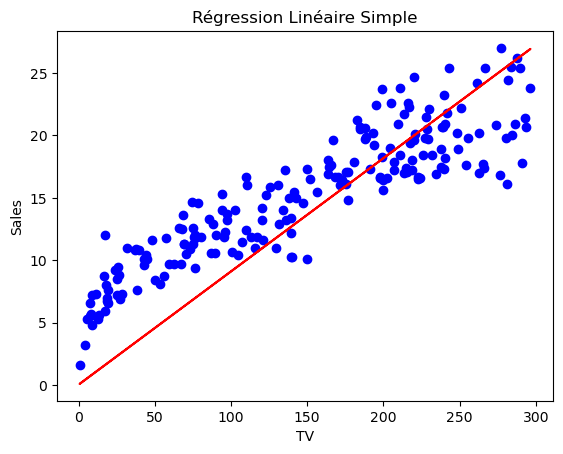

In [12]:

# Variable indépendante
X = df['TV'].values

# Variable dépendante
Y = df['Sales'].values

# Nombre de données
n = len(X)

# Initialisation
a = 0
b = 0

# Hyperparamètres
alpha = 0.00001
iterations = 1000

# Gradient Descent
for i in range(iterations):

    # Prédictions
    Y_pred = a * X + b

    # Erreur
    erreur = Y - Y_pred

    # Dérivées
    da = (-2/n) * np.sum(X * erreur)
    db = (-2/n) * np.sum(erreur)

    # Mise à jour
    a = a - alpha * da
    b = b - alpha * db

# Résultats
print("Pente a =", a)
print("Biais b =", b)

# Equation finale
print(f"Sales = {a} * TV + {b}")

# Nouvelle prédiction
tv = 200

prediction = a * tv + b

print("Prediction pour TV=200 :", prediction)

# Visualisation
plt.scatter(X, Y, color='blue')
plt.plot(X, a * X + b, color='red')

plt.xlabel("TV")
plt.ylabel("Sales")

plt.title("Régression Linéaire Simple")

plt.show()

#  <span style="color:blue">Régression multiple  FROM SCRATCH</span>


In [13]:
#  Calcul des coefficients (Équation Normale)

# Formule mathématique :
# β = (XᵀX)^(-1) Xᵀ y

# Où :
# Xᵀ = transpose de X
# (XᵀX)^(-1) = inverse de la matrice
# β = [b0, b1, b2, b3]

# Étapes du calcul :

# 1. XᵀX  → matrice de covariance
# 2. inverse(XᵀX)
# 3. multiplier par Xᵀ
# 4. multiplier par y


# Variables indépendantes
X = df[['TV', 'Radio', 'Newspaper']].values

# Variable dépendante
Y = df['Sales'].values

# Ajouter biais
ones = np.ones((X.shape[0], 1))
X = np.hstack((ones, X))

# Initialisation
theta = np.zeros(X.shape[1])

# Hyperparamètres
alpha = 0.000001
iterations = 10000
n = len(Y)

# Gradient Descent
for i in range(iterations):

    Y_pred = X.dot(theta)

    erreur = Y - Y_pred

    gradient = (-2/n) * X.T.dot(erreur)

    theta = theta - alpha * gradient

# Résultats
print("b =", theta[0])
print("a1 (TV) =", theta[1])
print("a2 (Radio) =", theta[2])
print("a3 (Newspaper) =", theta[3])

# Nouvelle prédiction
x_new = np.array([1, 200, 40, 50])

prediction = x_new.dot(theta)

print("Prediction =", prediction)

b = 0.015649534269521616
a1 (TV) = 0.06711452992428338
a2 (Radio) = 0.15740985567521873
a3 (Newspaper) = 0.02970260185030804
Prediction = 21.22007983865035


#  <span style="color:blue">Régression polynomiale FROM SCRATCH</span>


In [19]:

# X = variable indépendante
# Ici on utilise seulement la colonne TV
X = df["TV"].values

# Y = variable dépendante
# C'est ce qu'on veut prédire
Y = df["Sales"].values

# Calcul de la moyenne
X_mean = np.mean(X)

# Calcul de l'écart-type
X_std = np.std(X)

# Formule :
# X' = (X - moyenne) / écart-type
X_norm = (X - X_mean) / X_std

# Créer les features polynomiales

# np.c_ permet de concaténer les colonnes

# Colonne 1 :
# représente le biais b

# Colonne X :
# représente a1 * X

# Colonne X² :
# représente a2 * X²

# Forme finale :
# Y = b + a1X + a2X²

X_poly = np.c_[
    np.ones(len(X_norm)),
    X_norm,
    X_norm**2
]

#Initialisation des paramètres


# theta = [b, a1, a2]

theta = np.zeros(X_poly.shape[1])


# learning rate
alpha = 0.01

# nombre d'itérations
iterations = 10000

# nombre d'exemples
n = len(Y)

#  Gradient Descent
for i in range(iterations):
    # Formule :
    # Y_pred = X * theta

    Y_pred = X_poly.dot(theta)

    # erreur = réel - prédit

    erreur = Y - Y_pred

    # Formule :
    # gradient =
    # (-2/n) * X^T * erreur

    gradient = (-2/n) * X_poly.T.dot(erreur)

    # Mise à jour theta
    

    # Formule Gradient Descent :
    # theta = theta - alpha * gradient

    theta = theta - alpha * gradient

#  Afficher paramètres appris

print("b =", theta[0])
print("a1 =", theta[1])
print("a2 =", theta[2])


# . Faire une prédiction

# Nouvelle valeur TV
tv = 200

# IMPORTANT :
# normaliser avec même moyenne et std

tv_norm = (tv - X_mean) / X_std

# Créer vecteur polynomial
x_new = np.array([
    1,
    tv_norm,
    tv_norm**2
])

# Prédiction finale
prediction = x_new.dot(theta)

print("Prediction Sales =", prediction)



b = 15.740851584007812
a1 = 4.707651200672243
a2 = -0.6103515840078568
Prediction Sales = 18.41856733490183


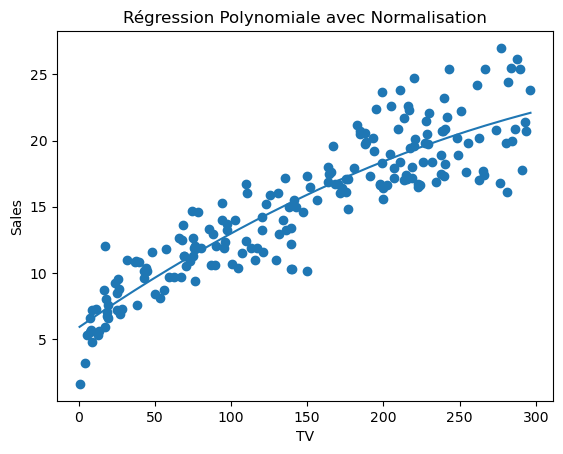

In [20]:
# Visualisation
X_sorted = np.sort(X)
X_sorted_norm = (X_sorted - X_mean) / X_std
X_sorted_poly = np.c_[np.ones(len(X_sorted_norm)), X_sorted_norm, X_sorted_norm**2]

Y_sorted_pred = X_sorted_poly.dot(theta)

plt.scatter(X, Y)
plt.plot(X_sorted, Y_sorted_pred)
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("Régression Polynomiale avec Normalisation")
plt.show()

#  <span style="color:blue">Logistic Regression</span>


In [21]:

#  Variables X et Y

# X = TV, Radio, Newspaper
X = df[["TV", "Radio", "Newspaper"]].values

# Y = classe
# 1 si Sales >= 15
# 0 si Sales < 15
Y = (df["Sales"] >= 15).astype(int).values

# Normalisation

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

X_norm = (X - X_mean) / X_std

# Ajouter biais

X_biais = np.c_[np.ones(X_norm.shape[0]), X_norm]

# theta = [b, a1, a2, a3]
theta = np.zeros(X_biais.shape[1])

# Fonction Sigmoid

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradient Descent

alpha = 0.01
iterations = 10000
n = len(Y)

for i in range(iterations):

    # z = Xθ
    z = X_biais.dot(theta)

    # probabilité entre 0 et 1
    Y_pred = sigmoid(z)

    # erreur
    erreur = Y_pred - Y

    # gradient
    gradient = (1/n) * X_biais.T.dot(erreur)

    # mise à jour
    theta = theta - alpha * gradient

#  Résultats

print("b =", theta[0])
print("a1 TV =", theta[1])
print("a2 Radio =", theta[2])
print("a3 Newspaper =", theta[3])

# 8. Prédiction

# Exemple : TV=200, Radio=40, Newspaper=50
x_new = np.array([[200, 40, 50]])

# normaliser avec même moyenne et std
x_new_norm = (x_new - X_mean) / X_std

# ajouter biais
x_new_biais = np.c_[np.ones(x_new_norm.shape[0]), x_new_norm]

# probabilité
prob = sigmoid(x_new_biais.dot(theta))

print("Probabilité =", prob[0])

if prob[0] >= 0.5:
    print("Classe = 1 : Sales élevé")
else:
    print("Classe = 0 : Sales faible")

b = 0.6826814798387026
a1 TV = 4.7816406572219545
a2 Radio = 1.2434809621092358
a3 Newspaper = 0.3552593779653624
Probabilité = 0.9953339941093977
Classe = 1 : Sales élevé
